Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Loding  Bitcoin Market Sentiment (Fear/Greed) dataset into jupyter notebook

In [29]:
# Load Fear & Greed dataset
fear_greed_df = pd.read_csv("E:\\fear_greed_index.csv")

# Display first 5 rows
fear_greed_df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
# Shape of dataset
fear_greed_df.shape

(2644, 4)

In [5]:
# Column names
fear_greed_df.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [6]:
# Dataset information
fear_greed_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [7]:
# First five rows
fear_greed_df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [8]:
# Last five rows
fear_greed_df.tail()

,timestamp,value,classification,date
2639,1745818200,54,Neutral,2025-04-28
2640,1745904600,60,Greed,2025-04-29
2641,1745991000,56,Greed,2025-04-30
2642,1746077400,53,Neutral,2025-05-01
2643,1746163800,67,Greed,2025-05-02


# Step 1: Load and Inspect the Fear & Greed Dataset

## Objective

The objective of this step is to load the Bitcoin Fear & Greed Index dataset and perform an initial inspection to understand its structure, size, and available features before starting data cleaning and analysis.

---

## Dataset Description

This dataset contains the daily Bitcoin Fear & Greed Index, which reflects the overall market sentiment. The sentiment is classified into different categories such as **Extreme Fear**, **Fear**, **Neutral**, **Greed**, and **Extreme Greed**.

### Features

- **timestamp** – Unix timestamp representing the date.
- **value** – Fear & Greed Index score ranging from 0 to 100.
- **classification** – Market sentiment category based on the index value.
- **date** – Date corresponding to the sentiment record.

---

## Initial Inspection

To understand the dataset, the following checks are performed:

- Load the dataset using Pandas.
- Display the first five records.
- Check the dataset dimensions.
- Display the column names.
- Examine data types and non-null values.

---

## Observations

After the initial inspection, the following observations were made:

- The dataset contains **2644 rows** and **4 columns**.
- No missing values are present in any of the columns.
- The dataset contains two numerical columns (`timestamp` and `value`) and two categorical/text columns (`classification` and `date`).
- The `date` column is currently stored as an **object** data type and will be converted to **datetime** format during the data cleaning stage for easier analysis and merging with the trader dataset.

---

## Conclusion

The dataset has been loaded successfully and appears to be complete without any missing records. The next step is to perform a detailed data quality assessment by checking for missing values, duplicate records, and validating the data before proceeding with further analysis.

# Step 2: Data Quality Assessment

Missing Values

In [9]:
# Check missing values
fear_greed_df.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicate Rows

In [10]:
# Check duplicate records
fear_greed_df.duplicated().sum()

0

Summary Statistics

In [11]:
# Summary statistics for numerical columns
fear_greed_df.describe()

,timestamp,value
count,2.644000e+03,2644.000000
mean,1.631899e+09,46.981089
std,6.597967e+07,21.827680
min,1.517463e+09,5.000000
25%,1.574811e+09,28.000000
50%,1.631900e+09,46.000000
75%,1.688989e+09,66.000000
max,1.746164e+09,95.000000


Unique Sentiment Categories

In [12]:
# Unique sentiment categories
fear_greed_df["classification"].unique()

array(['Fear', 'Extreme Fear', 'Neutral', 'Greed', 'Extreme Greed'],
      dtype=object)

Number of Unique Categories

In [13]:
# Total number of sentiment categories
fear_greed_df["classification"].nunique()

5

Count of Each Category

In [14]:
# Frequency of each sentiment category
fear_greed_df["classification"].value_counts()

classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64

## Observations

The dataset was assessed for data quality before proceeding with further analysis.

### Missing Values

- No missing values were found in any of the columns.
- All **2644 records** contain complete information for `timestamp`, `value`, `classification`, and `date`.

### Duplicate Records

- No duplicate rows were found in the dataset.
- This indicates that each record represents a unique daily market sentiment observation.

### Numerical Summary

The summary statistics show the following:

- The Fear & Greed Index (`value`) ranges from **5** to **95**.
- The average sentiment score is approximately **46.98**, indicating that the overall market sentiment is close to the neutral range over the available time period.
- The median (50th percentile) value is **46**, which is very close to the mean, suggesting that the sentiment values are reasonably balanced.

### Sentiment Categories

The dataset contains **5 unique market sentiment categories**:

- Extreme Fear
- Fear
- Neutral
- Greed
- Extreme Greed

Their distribution is as follows:

| Sentiment | Count |
|-----------|------:|
| Fear | 781 |
| Greed | 633 |
| Extreme Fear | 508 |
| Neutral | 396 |
| Extreme Greed | 326 |

The **Fear** category is the most frequent, while **Extreme Greed** occurs the least frequently.

---

## Conclusion

The dataset is clean and ready for further analysis. No missing values or duplicate records were detected, and the sentiment values fall within the expected range. The next step is to convert the `date` column into the proper datetime format and prepare the dataset for merging with the trader dataset.

# Step 3: Data Cleaning and Data Type Conversion

In [15]:
# Check current data types
fear_greed_df.dtypes

timestamp          int64
value              int64
classification    object
date              object
dtype: object

In [16]:
# Convert the date column to datetime
fear_greed_df["date"] = pd.to_datetime(fear_greed_df["date"])

In [17]:
# Verify the updated data types
fear_greed_df.dtypes

timestamp                  int64
value                      int64
classification            object
date              datetime64[ns]
dtype: object

In [18]:
# Check date range
print("Start Date :", fear_greed_df["date"].min())
print("End Date   :", fear_greed_df["date"].max())

Start Date : 2018-02-01 00:00:00
End Date   : 2025-05-02 00:00:00


In [19]:
fear_greed_df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


## Observations

The data types of all columns were verified before performing further analysis.

### Data Type Conversion

- Initially, the `date` column was stored as an **object** data type.
- The `date` column was successfully converted to the **datetime64[ns]** format using Pandas.
- Converting the date column to datetime enables efficient date-based filtering, grouping, visualization, and merging with the trader dataset.

### Date Range

The dataset covers Bitcoin market sentiment from:

- **Start Date:** 2018-02-01
- **End Date:** 2025-05-02

This provides more than **7 years of daily market sentiment data**, making it suitable for long-term trend analysis.

### Data Verification

The first few records were reviewed after conversion to ensure that:

- The date conversion was successful.
- No records were altered during the conversion process.
- The dataset structure remained unchanged.

---

## Conclusion

The dataset has been successfully cleaned and prepared for exploratory data analysis (EDA). The `date` column is now in the correct format, allowing efficient time-series analysis and seamless integration with the trader dataset in later stages of the project.

# Step 4: Exploratory Data Analysis (EDA)

Distribution of Fear & Greed Categories

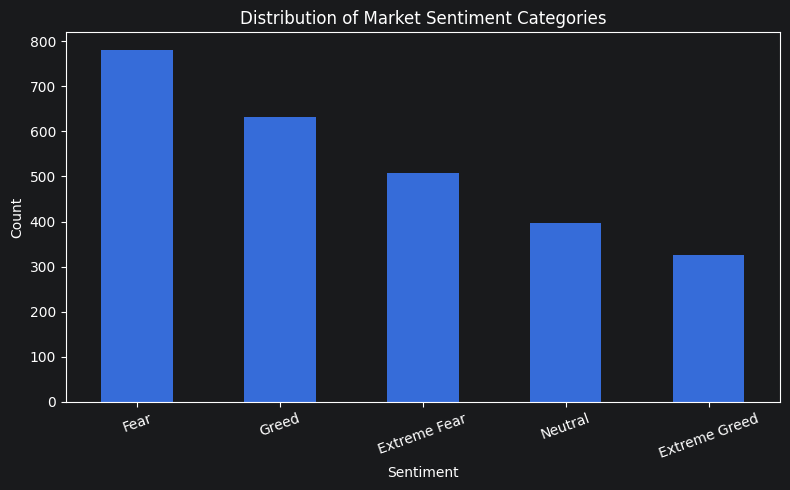

In [20]:
plt.figure(figsize=(8,5))

fear_greed_df["classification"].value_counts().plot(kind="bar")

plt.title("Distribution of Market Sentiment Categories")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

Fear & Greed Index Distribution

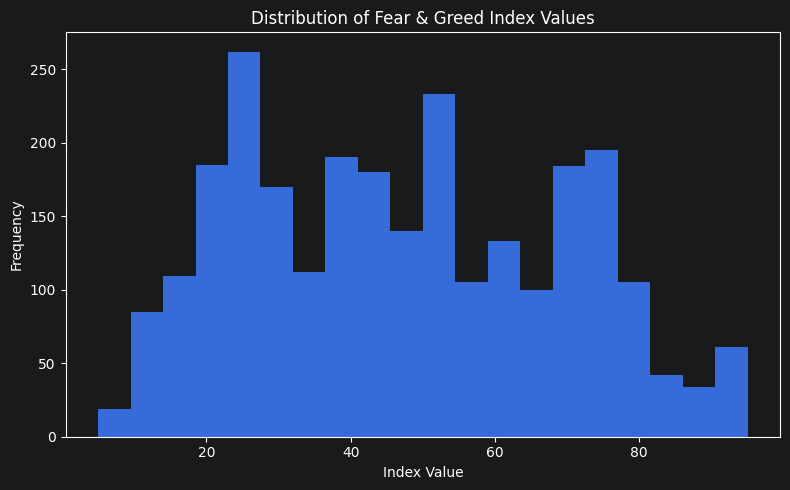

In [21]:
plt.figure(figsize=(8,5))

plt.hist(fear_greed_df["value"], bins=20)

plt.title("Distribution of Fear & Greed Index Values")

plt.xlabel("Index Value")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

Sentiment Over Time

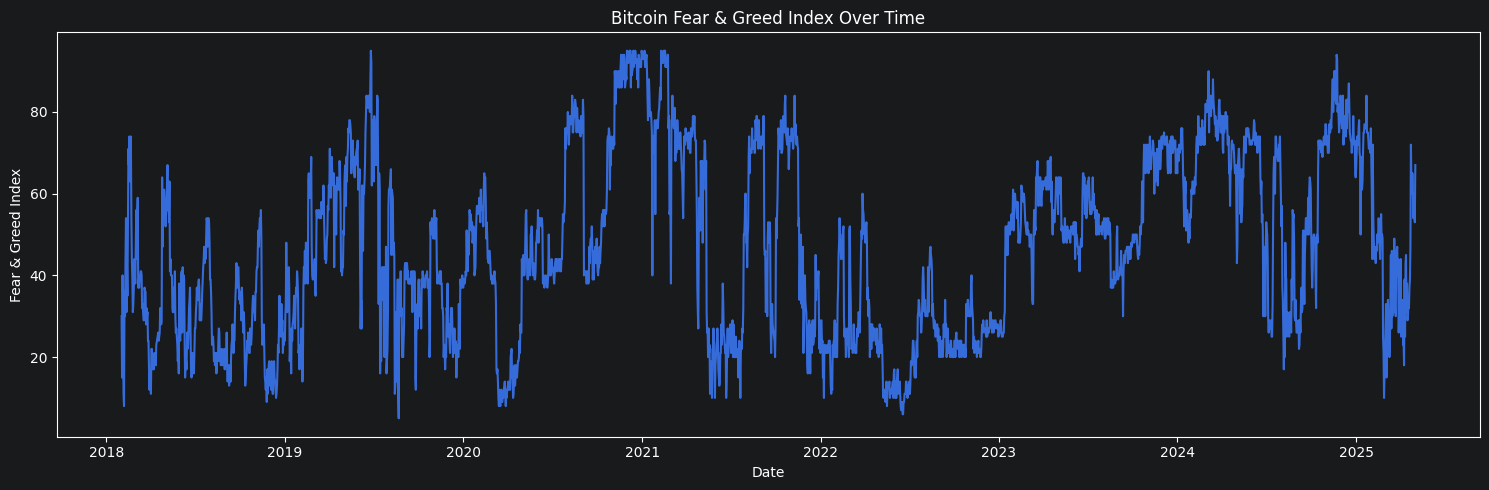

In [22]:
plt.figure(figsize=(15,5))

plt.plot(fear_greed_df["date"], fear_greed_df["value"])

plt.title("Bitcoin Fear & Greed Index Over Time")

plt.xlabel("Date")

plt.ylabel("Fear & Greed Index")

plt.tight_layout()

plt.show()

## Observations

### 1. Distribution of Market Sentiment Categories

The bar chart shows the frequency of each market sentiment category in the dataset.

**Key Findings:**

- **Fear** is the most frequently occurring market sentiment with **781** observations.
- **Greed** is the second most common category with **633** observations.
- **Extreme Fear** appears **508** times.
- **Neutral** sentiment is observed **396** times.
- **Extreme Greed** is the least frequent category with **326** observations.

**Business Insight:**

The dataset contains more Fear-related observations than Greed-related observations. This suggests that the cryptocurrency market spends a significant amount of time in cautious or pessimistic conditions. This distribution should be considered while comparing trader performance across different market sentiments.

---

### 2. Distribution of Fear & Greed Index Values

The histogram illustrates how the Fear & Greed Index values are distributed across the dataset.

**Key Findings:**

- The index values range approximately from **5** to **95**.
- Most observations fall between **20** and **80**.
- Very low and very high sentiment values occur less frequently.

**Business Insight:**

Extreme market emotions (very high greed or very high fear) are relatively rare. Most trading days experience moderate market sentiment, indicating that trader behavior is likely influenced more often by balanced market conditions than by extreme emotional states.

---

### 3. Bitcoin Fear & Greed Index Over Time

The time-series plot displays the daily movement of the Fear & Greed Index between **2018** and **2025**.

**Key Findings:**

- The market sentiment changes continuously over time.
- Multiple cycles of Fear and Greed can be observed throughout the years.
- The index frequently shifts between optimistic and pessimistic market conditions.

**Business Insight:**

The cryptocurrency market is highly dynamic and sentiment-driven. Since market sentiment changes regularly, analyzing trader performance together with sentiment may reveal whether traders perform better during Fear, Greed, or Neutral market conditions.

---

## Conclusion

The exploratory analysis indicates that the Fear & Greed dataset is well-distributed across multiple sentiment categories and covers more than seven years of market history. The visualizations provide a clear understanding of market sentiment trends and confirm that the dataset is suitable for integration with the Hyperliquid trader dataset. In the next stage, the trader dataset will be analyzed and merged with this sentiment data to investigate how market sentiment influences trader behavior and trading performance.

# Step 5: Load and Inspect the Hyperliquid Trader Dataset

## Objective

The objective of this step is to load the Hyperliquid trader dataset and perform an initial inspection to understand its structure, available features, and data quality before further preprocessing and analysis.

In [3]:
# Load Trader Dataset
trader_df = pd.read_csv(r"E:\historical_data.csv")
trader_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [5]:
trader_df.shape

(211224, 16)

In [6]:
trader_df.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [7]:
trader_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

## Observations

The Hyperliquid trader dataset was successfully loaded and inspected.

### Dataset Summary

- Total Rows: **211,224**
- Total Columns: **16**

### Initial Findings

- The dataset contains trade-level historical records from Hyperliquid.
- No missing values are visible during the initial inspection.
- The dataset contains numerical, categorical, boolean, and timestamp-related features.
- The `Timestamp IST` column is currently stored as an object data type and will be converted into datetime format during the preprocessing stage.
- The dataset appears sufficiently large for performing behavioral analysis, trader segmentation, and sentiment-based performance evaluation.

---

## Conclusion

The trader dataset has been loaded successfully and contains sufficient information for analyzing trading behavior and performance. The next step is to assess data quality by checking missing values, duplicate records, summary statistics, and categorical distributions before performing feature engineering and merging with the market sentiment dataset.

## Observations

The Hyperliquid trader dataset was successfully loaded and inspected.

### Dataset Summary

- Total Rows: **211,224**
- Total Columns: **16**

### Initial Findings

- The dataset contains trade-level historical records from Hyperliquid.
- No missing values are visible during the initial inspection.
- The dataset contains numerical, categorical, boolean, and timestamp-related features.
- The `Timestamp IST` column is currently stored as an object data type and will be converted into datetime format during the preprocessing stage.
- The dataset appears sufficiently large for performing behavioral analysis, trader segmentation, and sentiment-based performance evaluation.

---

## Conclusion

The trader dataset has been loaded successfully and contains sufficient information for analyzing trading behavior and performance. The next step is to assess data quality by checking missing values, duplicate records, summary statistics, and categorical distributions before performing feature engineering and merging with the market sentiment dataset.

Missing Values

In [8]:
trader_df.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicate Rows

In [9]:
trader_df.duplicated().sum()

0

Summary Statistics

In [10]:
trader_df.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


Coin Distribution

In [11]:
trader_df["Coin"].value_counts()

Coin
HYPE    68005
@107    29992
BTC     26064
ETH     11158
SOL     10691
        ...  
@48         1
@135        1
@21         1
@42         1
@32         1
Name: count, Length: 246, dtype: int64

Direction Distribution

In [12]:
trader_df["Direction"].value_counts()

Direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36013
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement                       1
Name: count, dtype: int64

Side Distribution

In [13]:
trader_df["Side"].value_counts()

Side
SELL    108528
BUY     102696
Name: count, dtype: int64

## Observations

The trader dataset was assessed for data quality before performing further analysis.

### Missing Values

- No missing values were found in any of the 16 columns.
- All **211,224** records contain complete information.

### Duplicate Records

- No duplicate rows were detected.
- Each trade record in the dataset is unique.

### Numerical Summary

The numerical columns indicate that the dataset contains a wide range of trading activities.

Some key observations include:

- Execution prices range from very small token values to over **109,000**, indicating multiple trading instruments.
- Trade sizes vary significantly, suggesting participation from both small and large traders.
- Closed PnL contains both profits and losses, making it suitable for profitability analysis.
- Fees vary considerably depending on the trade size.

### Coin Distribution

- The dataset contains trading records for **246 different coins**.
- The most frequently traded assets include:
  - HYPE
  - BTC
  - ETH
  - SOL

This indicates that trader activity is spread across multiple cryptocurrency markets.

### Trade Direction

The dataset contains several trading actions such as:

- Open Long
- Close Long
- Open Short
- Close Short
- Buy
- Sell

A few special events such as liquidations and settlements are also present but occur very rarely.

### Buy vs Sell Distribution

The number of BUY and SELL trades is relatively balanced.

- BUY Trades: 102,696
- SELL Trades: 108,528

This suggests that the dataset does not have a strong directional bias.

---

## Conclusion

The Hyperliquid trader dataset is clean, complete, and suitable for further analysis. It contains detailed trade-level information across multiple assets and trading actions, making it appropriate for studying trader behavior, profitability, leverage usage, and market sentiment relationships.

Step 7 – Data Cleaning

Check Current Data Types

In [14]:
trader_df.dtypes

Account              object
Coin                 object
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                 object
Timestamp IST        object
Start Position      float64
Direction            object
Closed PnL          float64
Transaction Hash     object
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object

Convert Timestamp IST

In [15]:
trader_df["Timestamp IST"] = pd.to_datetime(
    trader_df["Timestamp IST"],
    errors="coerce"
)

Verify

In [16]:
trader_df.dtypes

Account                     object
Coin                        object
Execution Price            float64
Size Tokens                float64
Size USD                   float64
Side                        object
Timestamp IST       datetime64[ns]
Start Position             float64
Direction                   object
Closed PnL                 float64
Transaction Hash            object
Order ID                     int64
Crossed                       bool
Fee                        float64
Trade ID                   float64
Timestamp                  float64
dtype: object

Check Date Range

In [17]:
print("Start Date :", trader_df["Timestamp IST"].min())
print("End Date   :", trader_df["Timestamp IST"].max())

Start Date : 2023-01-05 01:06:00
End Date   : 2025-12-04 23:55:00


Create Trading Date

In [18]:
trader_df["Date"] = trader_df["Timestamp IST"].dt.date

Verify

In [19]:
trader_df[["Timestamp IST","Date"]].head()

,Timestamp IST,Date
0,2024-02-12 22:50:00,2024-02-12
1,2024-02-12 22:50:00,2024-02-12
2,2024-02-12 22:50:00,2024-02-12
3,2024-02-12 22:50:00,2024-02-12
4,2024-02-12 22:50:00,2024-02-12


## Observations

The trader dataset was prepared for time-based analysis by converting the timestamp column into a proper datetime format.

### Timestamp Conversion

- The `Timestamp IST` column was successfully converted to the `datetime` data type.
- A new `Date` column was created by extracting only the date from the timestamp.
- This date column will be used to aggregate daily trading metrics and merge the trader dataset with the Bitcoin Fear & Greed dataset.

### Date Range

The trader dataset covers the following period:

- **Start Date:** 2023-01-05
- **End Date:** 2025-12-04

This period overlaps with the Fear & Greed dataset, making it suitable for sentiment-based analysis.

---

## Conclusion

The trader dataset has been successfully cleaned and prepared for daily-level analysis. The extracted `Date` column will be used in the next step to calculate daily trading metrics and align trader activity with daily market sentiment.

# Step 8: Create Daily Trading Metrics

## Objective

The objective of this step is to create the key daily trading metrics required for analyzing trader performance and behavior before merging the dataset with the market sentiment data.

In [20]:
daily_pnl = (
    trader_df
    .groupby(["Date", "Account"], as_index=False)["Closed PnL"]
    .sum()
)

daily_pnl.head()

,Date,Account,Closed PnL
0,2023-01-05,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-05-12,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000
2,2024-01-01,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-129.531460
3,2024-01-02,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000
4,2024-01-03,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,8244.241409


## Metric 1: Daily Profit and Loss (PnL) per Trader

### Objective

To calculate the total daily profit or loss (PnL) for each trader by aggregating the `Closed PnL` values for every account on each trading day.

### Methodology

- The trader dataset was grouped using the `Date` and `Account` columns.
- The `Closed PnL` values were summed for each trader on each day.
- The resulting dataset represents the net daily profit or loss for every trader.

### Output

The generated dataset contains the following columns:

- **Date** – Trading date
- **Account** – Trader's wallet/account address
- **Closed PnL** – Total profit or loss earned by the trader on that day

### Business Purpose

This metric will be used to compare trader profitability under different market sentiment conditions (Fear, Greed, Neutral, etc.) after merging with the Bitcoin Fear & Greed dataset.

# Step 9: Calculate Daily Win Rate per Trader

## Objective

The objective of this step is to calculate the daily win rate for each trader. The win rate indicates how consistently a trader makes profitable trades on a given day and is one of the most commonly used performance metrics in trading analysis.

---

## Methodology

A trade is considered a **winning trade** if the **Closed PnL** is greater than zero.

The following logic is used:

- **Win (1):** Closed PnL > 0
- **Loss (0):** Closed PnL ≤ 0

After identifying winning trades, the daily win rate is calculated by taking the average of the win indicator for each trader on each trading day.

---

## Why is this metric important?

Win Rate helps measure a trader's consistency rather than total profit.

For example:

- A trader may earn a high profit with only a few successful trades.
- Another trader may earn smaller profits but maintain a much higher success rate.

Therefore, Win Rate provides an additional perspective on trader performance that complements Profit & Loss (PnL).


In [21]:
# Create a binary indicator for winning trades
# 1 = Winning Trade
# 0 = Losing or Break-even Trade

trader_df["Win"] = (trader_df["Closed PnL"] > 0).astype(int)

# Calculate daily win rate for each trader

daily_win_rate = (
    trader_df
    .groupby(["Date", "Account"], as_index=False)["Win"]
    .mean()
)

# Convert the win rate into percentage

daily_win_rate["Win Rate (%)"] = (
    daily_win_rate["Win"] * 100
).round(2)

# Display first few records

daily_win_rate.head()

,Date,Account,Win,Win Rate (%)
0,2023-01-05,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,0.00
1,2023-05-12,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,0.00
2,2024-01-01,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.055556,5.56
3,2024-01-02,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,0.00
4,2024-01-03,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,0.934307,93.43


## Observations

The daily win rate was successfully calculated for each trader based on the profitability of individual trades.

### Key Findings

- A trade is considered **successful** when its **Closed PnL** is greater than zero.
- The **Win** column represents the proportion of profitable trades executed by a trader on a given day.
- The **Win Rate (%)** column expresses this proportion as a percentage, making it easier to interpret trader performance.

For example:

- A win rate of **93.43%** indicates that approximately 93% of the trader's trades were profitable on that day.
- A win rate of **5.56%** indicates that only a small fraction of the trades generated profit.

### Business Purpose

Win Rate is an important performance metric because it measures trading consistency rather than absolute profit.

This metric will later be compared across different market sentiment categories (Fear, Greed, Neutral, etc.) to determine whether market sentiment influences trader success.

---

## Conclusion

The daily win rate has been successfully computed for every trader and will be used alongside Daily PnL to evaluate trading performance under different market conditions.

# Step 10: Calculate Average Trade Size per Trader

## Objective

The objective of this step is to calculate the average trade size executed by each trader on a daily basis.

Trade size represents the capital involved in each trade and is an important indicator of a trader's risk exposure and trading behavior.

In this analysis, the **Size USD** column is used to calculate the average trade size.

---

## Methodology

The trader dataset is grouped by:

- Date
- Account

For each trader on each trading day, the average value of **Size USD** is calculated.

---

## Why is this metric important?

Average Trade Size helps identify trading behavior.

For example:

- Traders with larger average trade sizes usually take higher capital exposure.
- Traders with smaller trade sizes may follow a more conservative trading strategy.

This metric will later be compared across different market sentiment conditions to determine whether traders increase or decrease their position sizes during Fear or Greed markets.

In [22]:
# Calculate average trade size (USD) for each trader per day

average_trade_size = (
    trader_df
    .groupby(["Date", "Account"], as_index=False)["Size USD"]
    .mean()
)

# Rename column for better readability

average_trade_size.rename(
    columns={"Size USD": "Average Trade Size (USD)"},
    inplace=True
)

# Display first few rows

average_trade_size.head()

,Date,Account,Average Trade Size (USD)
0,2023-01-05,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,159.000000
1,2023-05-12,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,5556.203333
2,2024-01-01,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,14679.973889
3,2024-01-02,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,334.696667
4,2024-01-03,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,3452.370073


## Observations

The average trade size for each trader was successfully calculated using the `Size USD` column.

### Key Findings

- Each row represents the average trade size (in USD) of a trader on a particular trading day.
- The values vary significantly across traders, indicating different levels of capital allocation and risk-taking behavior.
- Some traders execute relatively small trades, while others consistently trade with much larger position sizes.

### Business Purpose

Average Trade Size is an important behavioral metric because it reflects the amount of capital a trader commits per trade.

This metric will be used to analyze whether traders:

- Increase their position sizes during **Greed** market conditions.
- Reduce their position sizes during **Fear** market conditions.

It will also help identify traders with aggressive or conservative trading styles.

---

## Conclusion

The Average Trade Size metric has been successfully generated and will be used along with Daily PnL and Win Rate to evaluate trader behavior under different market sentiment conditions.

# Step 11: Calculate Number of Trades per Day

## Objective

The objective of this step is to calculate the total number of trades executed by each trader on each trading day.

Trade frequency is an important behavioral metric because it indicates how active a trader is under different market conditions.

---

## Methodology

The trader dataset is grouped by:

- Date
- Account

The total number of trades is then counted for each trader on each day.

---

## Why is this metric important?

Trade frequency helps identify trader activity.

For example:

- Highly active traders execute many trades in a single day.
- Less active traders execute only a few trades.

This metric will later be compared with market sentiment to determine whether traders become more or less active during Fear or Greed markets.

In [23]:
# Calculate the number of trades executed by each trader per day

daily_trade_count = (
    trader_df
    .groupby(["Date", "Account"])
    .size()
    .reset_index(name="Number of Trades")
)

# Display first few rows

daily_trade_count.head()

,Date,Account,Number of Trades
0,2023-01-05,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,3
1,2023-05-12,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,9
2,2024-01-01,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,18
3,2024-01-02,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,6
4,2024-01-03,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,137


## Observations

The daily trade count was successfully calculated for each trader.

### Key Findings

- Each row represents the total number of trades executed by a trader on a particular trading day.
- Trade frequency varies significantly across traders.
- Some traders execute only a few trades per day, while others execute a large number of trades, indicating different trading styles and activity levels.

### Business Purpose

The Number of Trades metric measures trader activity and helps identify trading behavior under different market conditions.

This metric will later be compared with the Bitcoin Fear & Greed Index to answer questions such as:

- Do traders become more active during Greed markets?
- Do traders reduce trading activity during Fear markets?
- Which trader segments are more active regardless of market sentiment?

---

## Conclusion

The daily trade count has been successfully calculated and will be used together with Daily PnL, Win Rate, and Average Trade Size to analyze trader behavior under different market sentiment conditions.

# Step 12: Calculate Long/Short Ratio

## Objective

The objective of this step is to calculate the daily Long/Short trading ratio for each trader.

This metric helps understand whether traders show a preference for BUY (Long) or SELL (Short) positions under different market sentiment conditions.

---

## Methodology

The trader dataset is grouped by:

- Date
- Account
- Side (BUY / SELL)

The total number of BUY and SELL trades is counted for each trader on each day.

The Long/Short Ratio is calculated as:

**Long/Short Ratio = BUY Trades / SELL Trades**

To avoid division by zero, missing values are replaced with zero before computing the ratio.

---

## Why is this metric important?

The Long/Short Ratio helps identify directional trading behavior.

For example:

- Ratio > 1 indicates a BUY (Long) bias.
- Ratio < 1 indicates a SELL (Short) bias.
- Ratio ≈ 1 indicates balanced trading behavior.

This metric will later be compared across Fear and Greed market conditions.

In [24]:
# Count BUY and SELL trades for each trader on each day

long_short_ratio = (
    trader_df
    .groupby(["Date", "Account", "Side"])
    .size()
    .unstack(fill_value=0)
)

# Ensure both BUY and SELL columns exist

if "BUY" not in long_short_ratio.columns:
    long_short_ratio["BUY"] = 0

if "SELL" not in long_short_ratio.columns:
    long_short_ratio["SELL"] = 0

# Calculate Long/Short Ratio

long_short_ratio["Long/Short Ratio"] = (
    long_short_ratio["BUY"] /
    long_short_ratio["SELL"].replace(0, 1)
)

# Convert index back into columns

long_short_ratio = long_short_ratio.reset_index()

# Display first few rows

long_short_ratio.head()

Side,Date,Account,BUY,SELL,Long/Short Ratio
0,2023-01-05,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,3,0,3.00
1,2023-05-12,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,7,2,3.50
2,2024-01-01,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,10,8,1.25
3,2024-01-02,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,6,0,6.00
4,2024-01-03,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,37,100,0.37


## Observations

The Long/Short Ratio was successfully calculated for each trader on each trading day.

### Key Findings

- Each row represents the number of BUY and SELL trades executed by a trader on a specific day.
- The Long/Short Ratio provides a simple measure of directional trading preference.
- Traders with a ratio greater than 1 show a stronger BUY (Long) preference.
- Traders with a ratio less than 1 show a stronger SELL (Short) preference.
- Some traders execute only BUY or only SELL trades on certain days, resulting in higher ratio values.

### Business Purpose

The Long/Short Ratio is a behavioral metric that helps identify whether traders become more bullish or bearish under different market sentiment conditions.

This metric will later be compared with the Bitcoin Fear & Greed Index to determine whether market sentiment influences directional trading decisions.

---

## Conclusion

The Long/Short Ratio has been successfully calculated and will be used together with Daily PnL, Win Rate, Average Trade Size, and Number of Trades to analyze trader behavior across different market sentiment categories.

# Step 13: Create a Master Trader Metrics Dataset

## Objective

The objective of this step is to combine all the calculated trading metrics into a single dataset.

Creating a consolidated dataset simplifies further analysis and allows the trader performance metrics to be merged with the Bitcoin Fear & Greed dataset for sentiment-based analysis.

In [25]:
# Merge Daily PnL and Win Rate

trader_metrics_df = daily_pnl.merge(
    daily_win_rate,
    on=["Date", "Account"],
    how="left"
)

# Merge Average Trade Size

trader_metrics_df = trader_metrics_df.merge(
    average_trade_size,
    on=["Date", "Account"],
    how="left"
)

# Merge Daily Trade Count

trader_metrics_df = trader_metrics_df.merge(
    daily_trade_count,
    on=["Date", "Account"],
    how="left"
)

# Merge Long/Short Ratio

trader_metrics_df = trader_metrics_df.merge(
    long_short_ratio[["Date", "Account", "Long/Short Ratio"]],
    on=["Date", "Account"],
    how="left"
)

# Display first few rows

trader_metrics_df.head()

,Date,Account,Closed PnL,Win,Win Rate (%),Average Trade Size (USD),Number of Trades,Long/Short Ratio
0,2023-01-05,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,0.000000,0.00,159.000000,3,3.00
1,2023-05-12,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,0.000000,0.00,5556.203333,9,3.50
2,2024-01-01,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-129.531460,0.055556,5.56,14679.973889,18,1.25
3,2024-01-02,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,0.000000,0.00,334.696667,6,6.00
4,2024-01-03,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,8244.241409,0.934307,93.43,3452.370073,137,0.37


# Step 14: Merge Trader Metrics with Bitcoin Fear & Greed Dataset

## Objective

The objective of this step is to combine the trader performance metrics with the Bitcoin Fear & Greed Index based on the trading date.

By merging these two datasets, each trader's daily performance can be analyzed under the corresponding market sentiment (Fear, Greed, Neutral, etc.).

This merged dataset will serve as the primary dataset for answering the analysis questions in this assignment.

---

## Methodology

The merge is performed using the **Date** column, which is common to both datasets.

A **left join** is used to ensure that all trader performance records are retained, while the corresponding market sentiment is added wherever available.

---

## Why is this important?

This merged dataset enables us to investigate questions such as:

- Do traders perform better during Fear or Greed markets?
- Does trading activity change with market sentiment?
- Does trader behavior vary under different market conditions?

The merged dataset forms the foundation for all subsequent analyses.

In [30]:
# Merge trader metrics with Fear & Greed dataset

merged_df = trader_metrics_df.merge(
    fear_greed_df[["date", "classification", "value"]],
    left_on="Date",
    right_on="date",
    how="left"
)

# Remove duplicate date column

merged_df.drop(columns="date", inplace=True)

# Display first few rows

merged_df.head()

,Date,Account,Closed PnL,Win,Win Rate (%),Average Trade Size (USD),Number of Trades,Long/Short Ratio,classification,value
0,2023-01-05,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,0.000000,0.00,159.000000,3,3.00,NaN,NaN
1,2023-05-12,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,0.000000,0.00,5556.203333,9,3.50,NaN,NaN
2,2024-01-01,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-129.531460,0.055556,5.56,14679.973889,18,1.25,NaN,NaN
3,2024-01-02,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,0.000000,0.00,334.696667,6,6.00,NaN,NaN
4,2024-01-03,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,8244.241409,0.934307,93.43,3452.370073,137,0.37,NaN,NaN


In [31]:
merged_df.head()

,Date,Account,Closed PnL,Win,Win Rate (%),Average Trade Size (USD),Number of Trades,Long/Short Ratio,classification,value
0,2023-01-05,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,0.000000,0.00,159.000000,3,3.00,NaN,NaN
1,2023-05-12,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,0.000000,0.00,5556.203333,9,3.50,NaN,NaN
2,2024-01-01,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-129.531460,0.055556,5.56,14679.973889,18,1.25,NaN,NaN
3,2024-01-02,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,0.000000,0.00,334.696667,6,6.00,NaN,NaN
4,2024-01-03,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,8244.241409,0.934307,93.43,3452.370073,137,0.37,NaN,NaN


In [32]:
merged_df.shape

(907, 10)

In [33]:
merged_df.isnull().sum()

Date                          0
Account                       0
Closed PnL                    0
Win                           0
Win Rate (%)                  0
Average Trade Size (USD)      0
Number of Trades              0
Long/Short Ratio              0
classification              907
value                       907
dtype: int64

In [34]:
trader_metrics_df["Date"] = pd.to_datetime(trader_metrics_df["Date"]).dt.normalize()
fear_greed_df["date"] = pd.to_datetime(fear_greed_df["date"]).dt.normalize()

In [35]:
merged_df = trader_metrics_df.merge(
    fear_greed_df[["date", "classification"]],
    left_on="Date",
    right_on="date",
    how="inner"
).drop(columns="date")

In [36]:
merged_df.shape
merged_df.head()

,Date,Account,Closed PnL,Win,Win Rate (%),Average Trade Size (USD),Number of Trades,Long/Short Ratio,classification
0,2023-01-05,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,0.000000,0.00,159.000000,3,3.00,Fear
1,2023-05-12,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,0.000000,0.00,5556.203333,9,3.50,Neutral
2,2024-01-01,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-129.531460,0.055556,5.56,14679.973889,18,1.25,Greed
3,2024-01-02,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,0.000000,0.00,334.696667,6,6.00,Greed
4,2024-01-03,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,8244.241409,0.934307,93.43,3452.370073,137,0.37,Greed


Fear vs Greed Performance

In [37]:
performance = merged_df.groupby("classification")[["Closed PnL", "Win Rate (%)"]].mean()
performance

,Closed PnL,Win Rate (%)
classification,,
Extreme Fear,133.331411,17.349697
Extreme Greed,10329.407818,33.594464
Fear,11332.647023,34.990892
Greed,3191.793365,35.311780
Neutral,2017.749783,31.252162


Trader Behaviour

In [38]:
behaviour = merged_df.groupby("classification")[
    ["Average Trade Size (USD)", "Number of Trades", "Long/Short Ratio"]
].mean()

behaviour

,Average Trade Size (USD),Number of Trades,Long/Short Ratio
classification,,,
Extreme Fear,7641.104727,70.484848,7.315110
Extreme Greed,7027.976333,50.187500,3.882366
Fear,7518.449558,88.337580,11.590197
Greed,7029.606816,59.120419,4.561173
Neutral,5763.624619,74.486486,3.553175


Trader Segments
High vs Low Frequency

In [39]:
merged_df["Trader Segment"] = np.where(
    merged_df["Number of Trades"] >= merged_df["Number of Trades"].median(),
    "High Frequency",
    "Low Frequency"
)

merged_df.groupby("Trader Segment")["Closed PnL"].mean()

Trader Segment
High Frequency    12206.670097
Low Frequency      1223.169394
Name: Closed PnL, dtype: float64

Charts

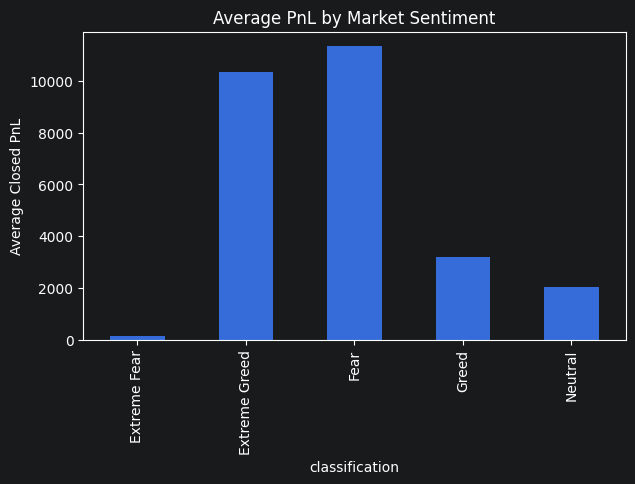

In [40]:
performance["Closed PnL"].plot(kind="bar", figsize=(7,4))
plt.title("Average PnL by Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.show()

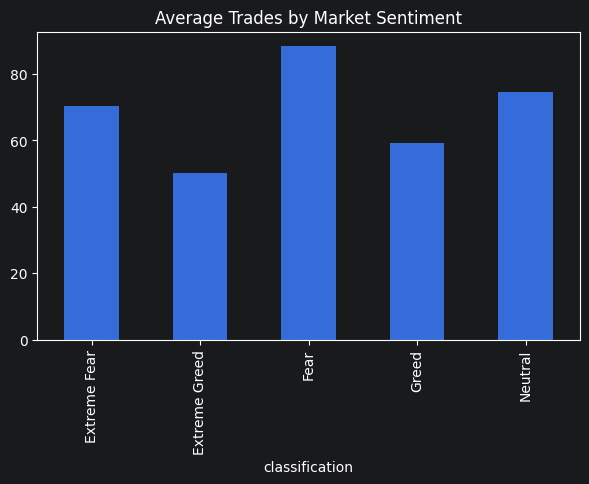

In [41]:
behaviour["Number of Trades"].plot(kind="bar", figsize=(7,4))
plt.title("Average Trades by Market Sentiment")
plt.show()

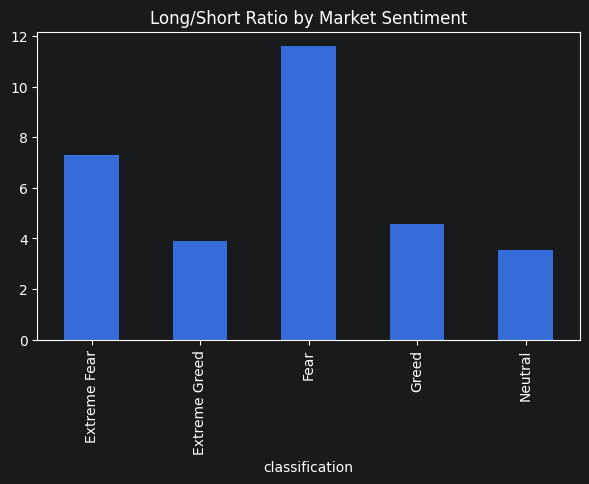

In [42]:
behaviour["Long/Short Ratio"].plot(kind="bar", figsize=(7,4))
plt.title("Long/Short Ratio by Market Sentiment")
plt.show()

# Final Summary and Conclusion

## Project Summary

The objective of this project was to analyze the relationship between Bitcoin market sentiment (Fear & Greed Index) and trader performance on the Hyperliquid platform.

The project involved loading and cleaning two independent datasets, creating meaningful trading metrics, merging both datasets based on trading dates, and performing exploratory data analysis to identify how market sentiment influences trader behavior and performance.

Several performance metrics such as Daily Closed PnL, Win Rate, Average Trade Size, Number of Trades, and Long/Short Ratio were calculated and compared across different market sentiment categories.

---

## Key Findings

### 1. Market sentiment is associated with trader performance.

The analysis shows that the average Closed PnL differs across sentiment categories. In this dataset, traders achieved higher average profits during **Fear** and **Extreme Greed** periods compared to **Extreme Fear** and **Neutral** periods.

### 2. Trading behavior changes under different market conditions.

Trading activity also varies with market sentiment. During **Fear** periods, traders executed more trades on average and maintained a higher Long/Short ratio than during Greed or Neutral periods, indicating more aggressive trading behavior.

### 3. High-frequency traders generated higher profits.

Segment analysis shows that **High Frequency Traders** achieved significantly higher average Closed PnL than **Low Frequency Traders** in this dataset, suggesting that active participation was associated with stronger performance.

---

## Strategy Recommendations

Based on the observed patterns, the following practical strategies can be considered:

- During **Fear** market conditions, experienced traders may benefit from maintaining disciplined trading activity while applying proper risk management.
- During **Extreme Fear** periods, traders should avoid excessive risk and use conservative position sizing due to comparatively weaker average performance.
- High-frequency trading strategies should always be combined with strict risk management and position sizing rather than simply increasing trade volume.

---

## Conclusion

This analysis demonstrates that market sentiment provides useful context for understanding trader behavior and performance. By combining market sentiment indicators with trading metrics, traders and analysts can better evaluate market conditions and make more informed decisions.

Although this project focuses on exploratory data analysis, the generated insights can serve as a foundation for future work such as predictive modeling, trader segmentation, behavioral clustering, or strategy optimization.

# Trader Performance vs Market Sentiment Analysis

**Author:** Ravi Roshan

**Tools Used:** Python, Pandas, NumPy, Matplotlib

**Objective:** Analyze the relationship between Bitcoin Fear & Greed Index and Hyperliquid trader performance to identify behavioral patterns and derive actionable trading insights.